# **Customer Service analysis**

Customer Shopping Behavior Analysis: Analyzed retail sales data using Python and Pandas to identify customer trends, product performance, regional sales patterns, and business insights through data cleaning, visualization, and exploratory data analysis. 📊🚀

In [3]:
from google.colab import files
uploaded_files = files.upload()

Saving superstore.csv.csv to superstore.csv (1).csv


here the dataste is uploaded


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('superstore.csv.csv')

loads the csv into dataframe

In [11]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


it shows first 5 rows

In [13]:
df.shape

(9800, 18)

shows no of rows and column

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

shows column name,data types,missing values

In [15]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


checks missing values

In [17]:
df.duplicated().sum()

np.int64(0)

checks duplicate record

In [20]:
df.drop_duplicates(inplace=True)

removes duplicates

In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

converts date

In [28]:
df['Sales'].sum()

np.float64(2261536.7827000003)

total sales

In [30]:
print("Available columns:")
print(df.columns)

Available columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


total available columns

In [31]:
df['Sales'].mean()

np.float64(230.7690594591837)

average sales

In [32]:
df['Order ID'].nunique()

4922

total orders

Category analysis

In [35]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,728658.5757
Office Supplies,705422.3340
Technology,827455.8730


sales by categoery


In [38]:
df.groupby('Category')['Region'].sum()

,Region
Category,
Furniture,SouthSouthSouthWestWestEastWestEastEastCentral...
Office Supplies,WestSouthWestWestWestSouthWestCentralCentralCe...
Technology,WestWestWestWestCentralCentralCentralCentralEa...


sales by region

In [39]:
df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
State,
California,446306.4635
New York,306361.1470
Texas,168572.5322
Washington,135206.8500
Pennsylvania,116276.6500
Florida,88436.5320
Illinois,79236.5170
Michigan,76136.0740
Ohio,75130.3500


Top states

Customer Analysis

In [40]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


top customer

In [41]:
df['Customer Name'].nunique()

793

Customer Count

**Product Analysis**

In [42]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


Best Selling products

**Time Analysis**

In [49]:
df['Month']=df['Order Date'].dt.month

create month column

In [50]:
df.groupby('Month')['Sales'].sum()

,Sales
Month,
1,94291.6296
2,59371.1154
3,197573.5872
4,136283.0006
5,154086.7237
6,145837.5233
7,145535.6890
8,157315.9270
9,300103.4117


Monthly Sales

# Visualisation

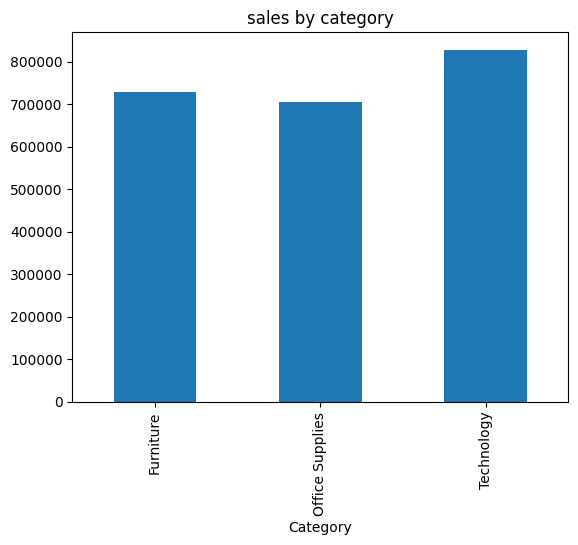

In [51]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('sales by category')
plt.show()

Bar chart

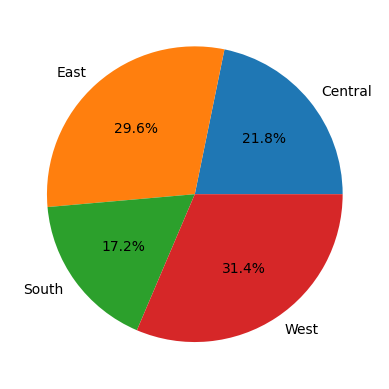

In [53]:
df.groupby('Region')['Sales'].sum().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.show()



pie chart

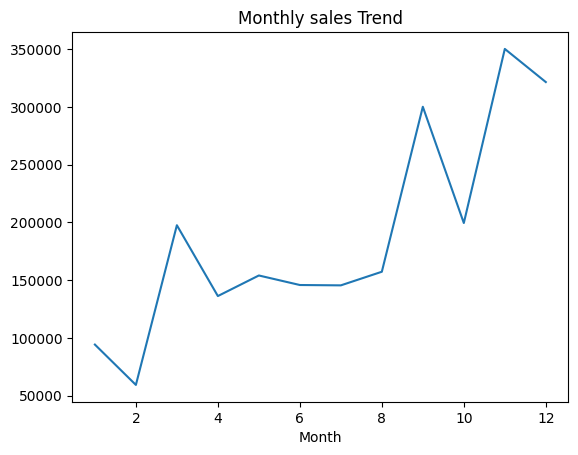

In [56]:
df.groupby('Month')['Sales'].sum().plot()
plt.title('Monthly sales Trend')
plt.show()

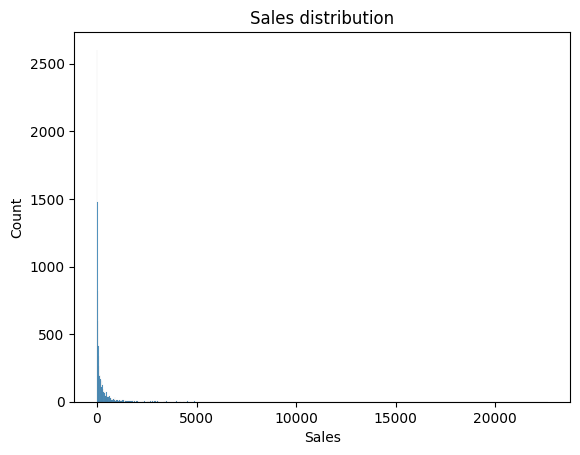

In [58]:
sns.histplot(df['Sales'])
plt.title('Sales distribution')
plt.show()

histogram

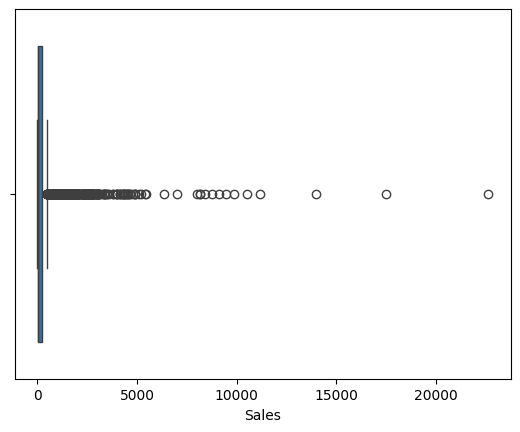

In [60]:
sns.boxplot(x=df['Sales'])
plt.show()

boxplot

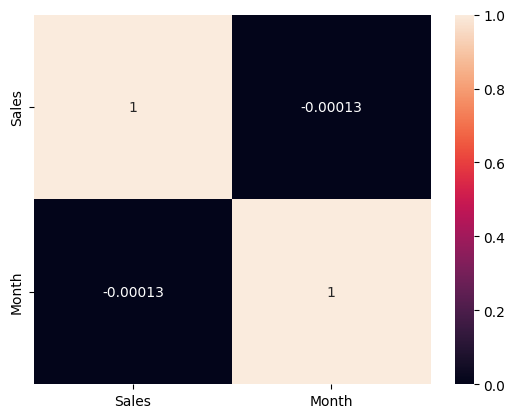

In [65]:
corr=df[['Sales','Month']].corr()
sns.heatmap(corr,annot=True)
plt.show()

Heatmap

BUSINESS INSIGHT

Insight 1

Technology category generates highest revenue.

Insight 2

West region contributes highest sales.

Insight 3

Few products generate majority of revenue.

Insight 4

Sales peak during specific months.

Insight 5

Some categories have high sales but low profit.

# FINAL PROJECT SUMMARY

Objective

Analyze customer shopping behavior and sales performance.

Tools Used

Python

Pandas

NumPy

Matplotlib

Seaborn

Google Colab


